# Programming exercise 3: Split step Fourier method

Due on Monday, 04.05.2026, 20h

## Defining the problem

We want to calculate the time evolution of a quantum particle in a on-dimensional potential, i.e. solve the initial value problem

$$ i\partial_t \psi(x,t) = \left[-\frac{1}{2} \partial_{x}^2 + V(x,t)\right] \psi(x,t) $$

with initial condition

$$ \psi(x,t=0) = \psi_0(x) $$

by representing the wave function $\psi(x,t)$ on a discrete spatial grid and propagating it using the split-step-Fourier method.

In [8]:
# load standard libraries

import numpy as np   # standard numerics library

import matplotlib.pyplot as plt   # for making plots
import scipy as sc

### Exercise 1

Write a function that calculates the discrete Fourier transform of a wave function. Use only even numbers of grid points. You have learned that the split-step-Fourier method automatically imposes periodic bounbdary conditions, so it makes sense to define the spatial grid like -L/2,-L/2+dx ... L/2-dx.

Hint: Try to avoid for-loops as they slow down your code. Work with the reshape command and use broadcasting where possible. Think about how you want to normalize the Fourier transform.

Test your function by Fourier transforming functions where you know what the outcome should be, e.g. a constant function, a delta function etc.
Implement also the inverse Fourier transform. Make sure you get back the original function after applying the FT and inverse FT.

Numpy provides a fast Fourier transform module. Compare your manual FT the result of the fast Fourier algorithm. Pay special attention to the ordering in which the Fourier components are returned by the FFT. You can get the k-values (up to a factor of $2\pi$) corresponding to the components of the vector returned by fft from np.fft.fftfreq(npoints,d=dx).

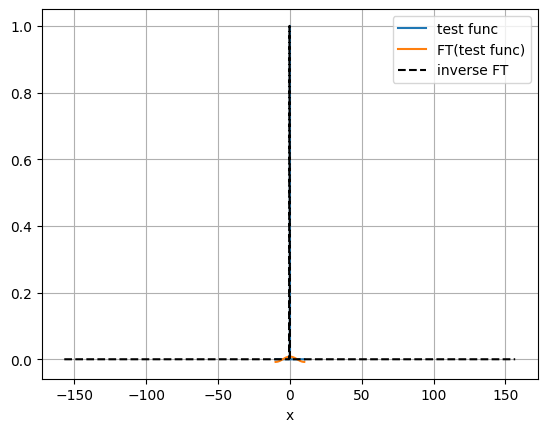

In [ ]:
L = 20
npoints = 1000

#discretizing position space
dx = L/npoints
xvals = np.arange(-L/2,L/2,dx)

#discretizing momentum space
dp = 2*np.pi/L
pvals= np.arange(-npoints/2*dp,npoints/2*dp, dp)

#Fourier Transformation
def FT(psi,pvals):
    phase = np.exp(-1j*pvals[:,None]*xvals[None,:])
    phi = 1/(np.sqrt(2*np.pi))*np.sum(phase * psi[None,:],1)*dx
    return phi

#Inverse FT
def inv_FT(phi,xvals):
    phase = np.exp(1j*xvals[:,None]*pvals[None,:])
    psi = 1/(np.sqrt(2*np.pi))*np.sum(phase * phi[None,:],1)*dp
    return psi


#FT and Invers_FT working, open is runtime and different test functions

#implement different def for discrete FT from script?

#test function 
delta_func = np.zeros(xvals.size)
delta_func[499] = 1

#plot
plt.plot(xvals,delta_func,label="test func")
plt.plot(xvals,FT(delta_func,pvals),label="FT(test func)")
plt.plot(pvals,inv_FT(FT(delta_func,pvals),xvals),"k--",label="inverse FT")
plt.grid()
plt.xlabel("x")
plt.legend()
plt.show() 


### Exercise 2

Implement the split step Fourier algorithm using the numpy FFT and iFFT functions.

Test your code by propagating a Gaussian wave packet in free space. 
Calculate mean and variance at each time and plot them. Does your observation match your expectation?
Below there are some example parameters that you could use.

Animate the time evolution of the wave packet using the method from programming exercise 2.

Optional: Compare the results to the exact analytical solution for a propagating wave packet. Try to increase the spatial and temporal step size to see how the error depends on them. You can also look at the wave packet in Fourier space, where the analytical solution is even simpler. What happens when you make the initial momentum p0 really large? Can you understand this by looking at the wave packet in momentum space?

In [4]:
# define the grid
L = 20
npoints = 256

# parameters of the wave packet
x0 = -5;
sigma = 1;
p0 = 1;

#time steps
dt = 0.1;
tsteps = 50;

### Exercise 3 (optional)

Experiment with differnet potentials!

Let the wave packet from before evolve in a harmonic potential (with p0=0). Can you recover the coherent state dynamics from programming exercise 2?
Again, calculate temporal evolution of mean and variance and visualize the wave packet evolution in an animation. Comment on your observations.

Now simulate the scattering off a potential step $V(x)\propto\theta(x)$. Choose different initial velocities (momenta). Interpret your results. What happens when the reflected wave packet reaches the boundary of the spatial grid? Example parameters are given below. Make sure your results are converged with respect to spatial and temporal step size and spatial grid size.

Be creative! Let your wave packet propagate through a potential barrier, across a well, or down a step etc. Measure the reflected and transmitted probability (and the probability to be inside the barrier) as a function of time and study the transmission systematically as a function of the initial momentum. Try out time dependent potentials, such as a barrier of oscillating height or position.

General hint: Pay attention to the data type of vectors. If you use containers for storing the wave function, make sure you initialize them as complex vectors.

In [5]:
# define the grid
L = 40
npoints = 512

# parameters of the wave packet
x0 = -10;
sigma = 2;
p0 = 1;# try also 1.5 and 2

#time steps
dt = 0.1;
tsteps = 250;